<a href="https://colab.research.google.com/github/DarshiniMahesh/AI-Practice/blob/main/Sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d snap/amazon-fine-food-reviews

Dataset URL: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
License(s): CC0-1.0
amazon-fine-food-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/amazon-fine-food-reviews.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
import nltk
import tensorflow as tf

In [ ]:
# Step 2: Load Dataset
df = pd.read_csv('/content/Reviews.csv')

# Step 3: Display Dataset Information
print(df.shape)

(568454, 10)


In [ ]:
# Step 4: View First 500 Rows
df.head(500)

# Step 5: View Last 500 Rows
df.tail(500)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
567954,567955,B0030VJ8YU,A2CW96MG1IB65L,Lola,0,0,2,1307404800,I wish my toddler liked it,I really wish my toddler liked this. It seems ...
567955,567956,B0030VJ8YU,A3P9MK4EKMA892,PeruMom,0,0,1,1306800000,Yuck!,I (and my little guy) have loved almost all ot...
567956,567957,B0030VJ8YU,A3MJNJLRCJWO9V,JessicaH,0,0,2,1305331200,Smells like cat food,I wanted this for the omega 3's but my daughte...
567957,567958,B0030VJ8YU,A2MF0C4E7GYCI,"VW ""VW""",0,0,5,1305331200,My son loves this,My son loves this food. He is 16 months now a...
567958,567959,B0030VJ8YU,A2MF0C4E7GYCI,"VW ""VW""",0,0,5,1305331200,My son loves this,My son loves this food. He is 16 months now a...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


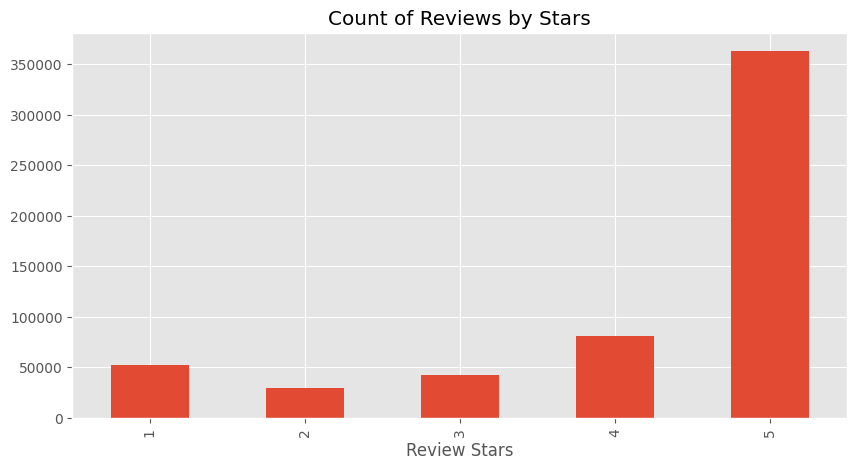

In [ ]:
# Step 6: Data Visualization (Review Distribution by Score)

ax = df['Score'].value_counts().sort_index().plot(
    kind='bar',
    title='Count of Reviews by Stars',
    figsize=(10,5)
)

ax.set_xlabel('Review Stars')
plt.show()

In [ ]:
# Step 7: Extract Sample Text (Text Exploration)

example = df['Text'][50]
example

"This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go."

In [ ]:
# Step 8: Download NLTK Tokenizer (Resource Setup)
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Step 9: Tokenization (Text Preprocessing)

tokens = nltk.word_tokenize(example)
tokens[:10]

['This', 'oatmeal', 'is', 'not', 'good', '.', 'Its', 'mushy', ',', 'soft']

In [ ]:
# Step 10: Download POS Tagger (NLTK Resource Setup)
import nltk
nltk.download('averaged_perceptron_tagger_eng')

# Step 11: Part-of-Speech Tagging (POS Tagging)
tagged = nltk.pos_tag(tokens)
tagged[:10]

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


[('This', 'DT'),
 ('oatmeal', 'NN'),
 ('is', 'VBZ'),
 ('not', 'RB'),
 ('good', 'JJ'),
 ('.', '.'),
 ('Its', 'PRP$'),
 ('mushy', 'NN'),
 (',', ','),
 ('soft', 'JJ')]

In [ ]:
# Step 12: Named Entity Recognition (NER Setup)
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

# Step 13: Named Entity Recognition (NER Execution)
entities = nltk.chunk.ne_chunk(tagged)

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


In [ ]:
# Step 14: Import Sentiment Analyzer (VADER Setup)
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

nltk.download('vader_lexicon')

# Step 15: Initialize Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
# Step 16: Test Sentiment Scores (Sample Inputs)
sia.polarity_scores('I am so happy!')
sia.polarity_scores('This is the worst thing ever.')
sia.polarity_scores(example)

{'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

In [ ]:
# Step 17: Apply Sentiment Analysis to Entire Dataset

res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Text']
    myid = row['Id']
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/568454 [00:00<?, ?it/s]

In [ ]:
# Step 18: Convert Sentiment Results to DataFrame

vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
vaders = vaders.merge(df, how='left')
vaders.head()

,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
# Step 18: Convert Sentiment Results to DataFrame

vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
vaders = vaders.merge(df, how='left')
vaders.head()

,Id,neg,neu,pos,compound,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


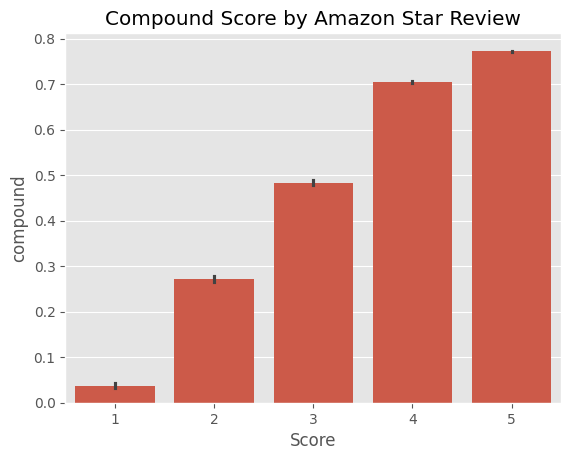

In [ ]:
# Step 19: Visualization - Compound Score vs Review Stars

ax = sns.barplot(data=vaders, x="Score", y="compound")
ax.set_title("Compound Score by Amazon Star Review")
plt.show()

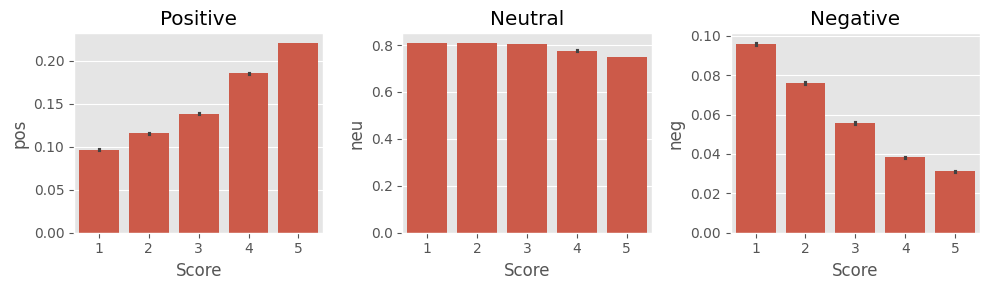

In [ ]:
# Step 20: Visualization - Positive, Neutral, Negative Scores

fig, axs = plt.subplots(1, 3, figsize=(10,3))

sns.barplot(data=vaders, x="Score", y="pos", ax=axs[0])
sns.barplot(data=vaders, x="Score", y="neu", ax=axs[1])
sns.barplot(data=vaders, x="Score", y="neg", ax=axs[2])

axs[0].set_title("Positive")
axs[1].set_title("Neutral")
axs[2].set_title("Negative")

plt.tight_layout()
plt.show()

In [ ]:
# Step 21: Install Required Libraries (Transformers & PyTorch)

!pip install transformers
!pip install torch torchvision

In [ ]:
# Step 22: Import Transformer Model (RoBERTa Sentiment Model)

from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Step 23: Apply RoBERTa Model on Sample Text

encoded_text = tokenizer(example, return_tensors='pt')
output = model(**encoded_text)

scores = output[0][0].detach().numpy()
scores = softmax(scores)

scores_dict = {
    'roberta_neg': scores[0],
    'roberta_neu': scores[1],
    'roberta_pos': scores[2]
}

print(scores_dict)

{'roberta_neg': np.float32(0.97635514), 'roberta_neu': np.float32(0.020687465), 'roberta_pos': np.float32(0.0029573692)}


In [ ]:
# Step 24: Create Function for RoBERTa Sentiment Scoring

def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)

    scores_dict = {
        'roberta_neg': scores[0],
        'roberta_neu': scores[1],
        'roberta_pos': scores[2]
    }

    return scores_dict

In [ ]:
# Step 25 REPLACEMENT — Fast version (500 rows only, ~2 mins instead of 60)
from tqdm.notebook import tqdm

# Use only first 500 rows so it finishes quickly
df_small = df.head(500)

res = {}

for i, row in tqdm(df_small.iterrows(), total=len(df_small)):
    try:
        text = row['Text']
        myid = row['Id']

        vader_result = sia.polarity_scores(text)
        vader_result_rename = {f"vader_{k}": v for k, v in vader_result.items()}

        roberta_result = polarity_scores_roberta(text)

        res[myid] = {**vader_result_rename, **roberta_result}

    except RuntimeError:
        print(f"Broke for id {myid}")

# Step 26 stays exactly the same
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'Id'})
results_df = results_df.merge(df, how='left')
results_df.head()

In [ ]:
# Step 26: Convert Results to DataFrame

results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'Id'})
results_df = results_df.merge(df, how='left')
results_df.head()

,Id,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,0.000,0.695,0.305,0.9441,0.009624,0.049980,0.940395,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,0.138,0.862,0.000,-0.5664,0.508986,0.452414,0.038600,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,0.091,0.754,0.155,0.8265,0.003229,0.098067,0.898704,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,0.000,1.000,0.000,0.0000,0.002295,0.090219,0.907486,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,0.000,0.552,0.448,0.9468,0.001635,0.010302,0.988063,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
# Step 27: Inspect Columns

results_df.columns

Index(['Id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'ProductId', 'UserId',
       'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator',
       'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

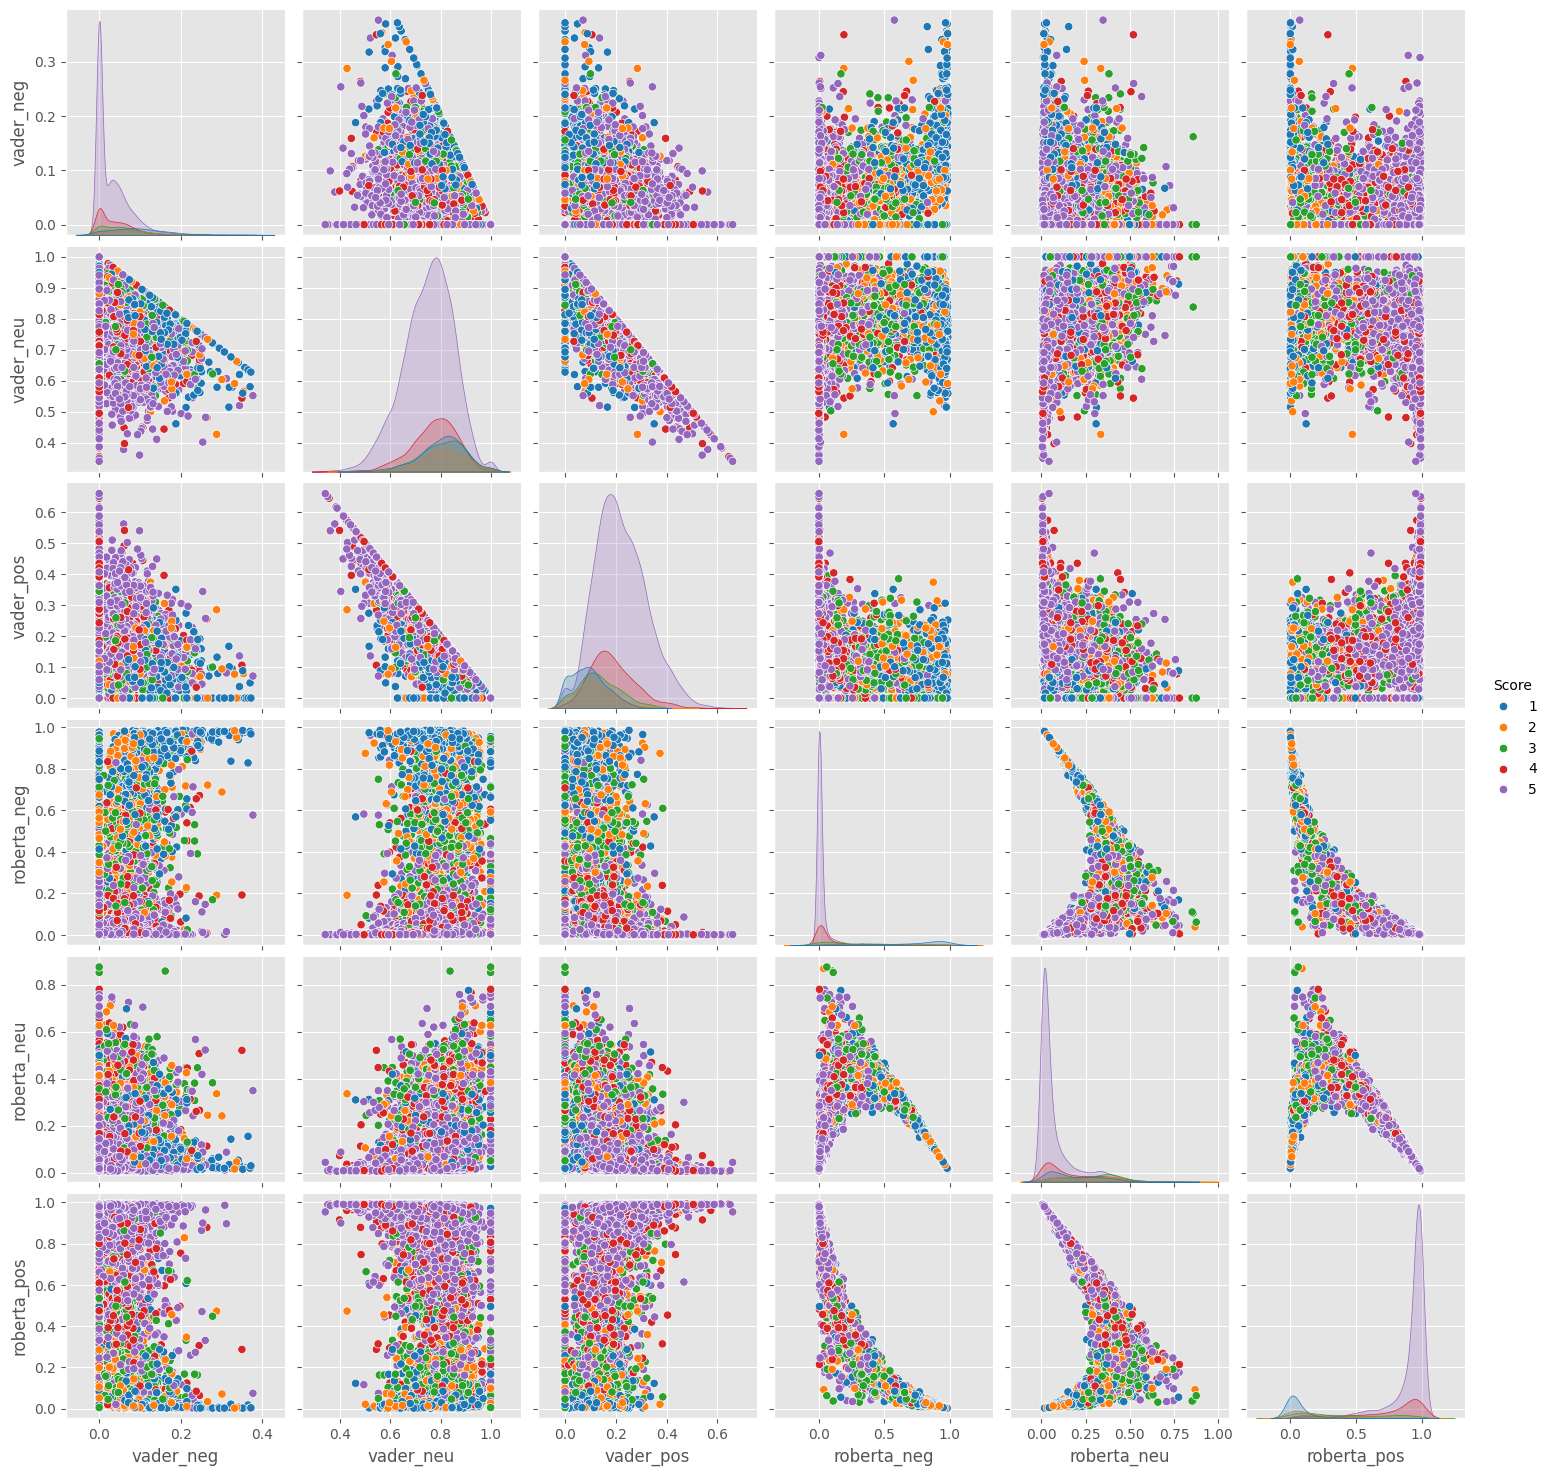

In [ ]:
# Step 28: Pairplot Comparison (VADER vs RoBERTa)

sns.pairplot(
    data=results_df,
    vars=['vader_neg','vader_neu','vader_pos',
          'roberta_neg','roberta_neu','roberta_pos'],
    hue='Score',
    palette='tab10'
)

plt.show()

In [ ]:
# Step 29: Analyze Extreme Reviews

results_df.query('Score==1') \
    .sort_values('roberta_pos', ascending=False)['Text'].values[0]

results_df.query('Score==5') \
    .sort_values('roberta_neg', ascending=False)['Text'].values[0]

results_df.query('Score==5') \
    .sort_values('vader_neg', ascending=False)['Text'].values[0]

'My two cats must not be interested in grass, because it grew but they ignored it. Had no problems growing it.'

In [ ]:
# Step 30: Use HuggingFace Pipeline (Simplified Sentiment Model)

from transformers import pipeline

sent_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# Step 31: Test Pipeline Predictions

sent_pipeline('Pizza tastes too good!')
#sent_pipeline('I hate everything')

[{'label': 'POSITIVE', 'score': 0.9990485310554504}]

In [ ]:
# ============================================================
# CELL 1: Install
# ============================================================
!pip install gradio transformers torch scipy nltk --quiet

# ============================================================
# CELL 2: All imports & model setup
# ============================================================
import gradio as gr
import nltk
import torch
import numpy as np
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from scipy.special import softmax

nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt',         quiet=True)

# VADER
sia = SentimentIntensityAnalyzer()

# RoBERTa
MODEL    = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer     = AutoTokenizer.from_pretrained(MODEL)
roberta_model = AutoModelForSequenceClassification.from_pretrained(MODEL)

# HuggingFace pipeline
hf_pipeline = pipeline("sentiment-analysis")

# ============================================================
# CELL 3: Scoring helpers
# ============================================================
def vader_scores(text):
    s = sia.polarity_scores(text)
    return s['neg'], s['neu'], s['pos'], s['compound']

def roberta_scores(text):
    enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
    with torch.no_grad():
        out = roberta_model(**enc)
    sc = softmax(out[0][0].numpy())
    return float(sc[0]), float(sc[1]), float(sc[2])

def hf_score(text):
    result = hf_pipeline(text[:512])[0]
    return result['label'], round(result['score'] * 100, 2)

def compound_label(c):
    if c >= 0.05:  return "🟢 Positive"
    if c <= -0.05: return "🔴 Negative"
    return "🟡 Neutral"

# ============================================================
# CELL 4: Main analysis function
# ============================================================
def analyse(text):
    if not text.strip():
        empty = {"Positive": 0, "Neutral": 0, "Negative": 0}
        return empty, empty, "—", "—", "—", "—", "—"

    # VADER
    v_neg, v_neu, v_pos, v_comp = vader_scores(text)
    vader_out = {
        "Positive": round(v_pos, 4),
        "Neutral":  round(v_neu, 4),
        "Negative": round(v_neg, 4),
    }

    # RoBERTa
    r_neg, r_neu, r_pos = roberta_scores(text)
    roberta_out = {
        "Positive": round(r_pos, 4),
        "Neutral":  round(r_neu, 4),
        "Negative": round(r_neg, 4),
    }

    # HuggingFace pipeline
    hf_label, hf_conf = hf_score(text)

    # Verdict
    v_verdict = compound_label(v_comp)
    r_verdict = ("🟢 Positive" if r_pos > r_neg and r_pos > r_neu
                 else "🔴 Negative" if r_neg > r_pos and r_neg > r_neu
                 else "🟡 Neutral")

    # Agreement
    v_lbl = ("positive" if v_comp >= 0.05 else "negative" if v_comp <= -0.05 else "neutral")
    r_lbl = ("positive" if r_pos > r_neg and r_pos > r_neu
              else "negative" if r_neg > r_pos and r_neg > r_neu else "neutral")
    agreement = (
        "✅ All 3 models agree!"
        if v_lbl == r_lbl == hf_label.lower()
        else f"⚠️ Models disagree — VADER: {v_lbl} | RoBERTa: {r_lbl} | Pipeline: {hf_label.lower()}"
    )

    # Compound display
    comp_display = f"{v_comp:+.4f}  →  {v_verdict}"

    # Pipeline display
    hf_display = f"{hf_label}  ({hf_conf}% confidence)"

    return (
        vader_out,
        roberta_out,
        comp_display,
        v_verdict,
        r_verdict,
        hf_display,
        agreement,
    )

# ============================================================
# CELL 5: Gradio UI
# ============================================================
EXAMPLES = [
    ["Pizza tastes too good!"],
    ["I hate everything about this product."],
    ["It's okay. Does the job but nothing special."],
    ["Absolutely amazing quality! Best purchase ever."],
    ["Terrible. Broke on day one. Total waste of money."],
    ["Not bad, some things are great, others disappointing."],
    ["I hate it but somehow I keep buying it every month."],
    ["This is the worst thing that has ever happened to me."],
]

css = """
/* ── Page ── */
body { background: #0d0f1a !important; }
.gradio-container {
    max-width: 980px !important;
    margin: 0 auto !important;
    font-family: 'Inter', sans-serif !important;
}

/* ── Header ── */
#header-html {
    text-align: center;
    padding: 32px 0 20px;
}
#header-html h1 {
    font-size: 2.2rem;
    font-weight: 700;
    background: linear-gradient(135deg, #a78bfa, #7c6cfc, #60a5fa);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin: 0 0 6px;
}
#header-html p {
    color: #8892a4;
    font-size: 0.95rem;
    margin: 0;
}

/* ── Textarea ── */
textarea {
    background: #1a1d2e !important;
    border: 1px solid #2e3250 !important;
    border-radius: 12px !important;
    color: #e2e8f0 !important;
    font-size: 0.95rem !important;
    line-height: 1.6 !important;
    resize: vertical !important;
}
textarea:focus {
    border-color: #7c6cfc !important;
    box-shadow: 0 0 0 3px rgba(124,108,252,0.15) !important;
}

/* ── Buttons ── */
.analyse-btn {
    background: linear-gradient(135deg, #7c6cfc, #5a4fcf) !important;
    border: none !important;
    border-radius: 10px !important;
    color: white !important;
    font-weight: 600 !important;
    font-size: 0.95rem !important;
    padding: 12px !important;
    transition: all 0.2s !important;
}
.analyse-btn:hover {
    transform: translateY(-1px) !important;
    box-shadow: 0 4px 20px rgba(124,108,252,0.4) !important;
}
.clear-btn {
    background: #1a1d2e !important;
    border: 1px solid #2e3250 !important;
    border-radius: 10px !important;
    color: #8892a4 !important;
    font-size: 0.9rem !important;
}
.clear-btn:hover { color: #e2e8f0 !important; border-color: #5a6080 !important; }

/* ── Cards ── */
.model-card {
    background: #1a1d2e !important;
    border: 1px solid #2e3250 !important;
    border-radius: 14px !important;
    padding: 20px !important;
}

/* ── Labels (score display) ── */
.label-wrap span {
    background: #21253a !important;
    border: 1px solid #2e3250 !important;
    border-radius: 8px !important;
    color: #e2e8f0 !important;
    font-size: 0.88rem !important;
}

/* ── Verdict boxes ── */
.verdict-box {
    background: #21253a !important;
    border: 1px solid #2e3250 !important;
    border-radius: 10px !important;
    padding: 14px 18px !important;
    font-size: 1rem !important;
    font-weight: 600 !important;
    text-align: center !important;
    color: #e2e8f0 !important;
}

/* ── Agreement banner ── */
.agree-banner {
    border-radius: 12px !important;
    padding: 16px !important;
    font-size: 0.95rem !important;
    font-weight: 500 !important;
    text-align: center !important;
}

/* ── Section headings ── */
.section-head {
    color: #8892a4 !important;
    font-size: 0.78rem !important;
    font-weight: 600 !important;
    letter-spacing: 0.1em !important;
    text-transform: uppercase !important;
    margin-bottom: 4px !important;
}

/* ── Examples ── */
.examples-table td {
    background: #1a1d2e !important;
    border: 1px solid #2e3250 !important;
    border-radius: 8px !important;
    color: #8892a4 !important;
    font-size: 0.82rem !important;
    padding: 6px 12px !important;
    cursor: pointer !important;
    transition: all 0.15s !important;
}
.examples-table td:hover { color: #a78bfa !important; border-color: #7c6cfc !important; }

/* hide footer */
footer { display: none !important; }
"""

with gr.Blocks(
    theme=gr.themes.Base(
        primary_hue="violet",
        neutral_hue="slate",
        font=[gr.themes.GoogleFont("Inter"), "sans-serif"]
    ),
    css=css,
    title="Sentiment Analyser"
) as demo:

    # ── Header ──
    gr.HTML("""
    <div id="header-html">
        <h1>🧠 Sentiment Analyser</h1>
        <p>Compare VADER · RoBERTa · HuggingFace Pipeline — all three at once</p>
    </div>
    """)

    # ── Input section ──
    with gr.Group(elem_classes="model-card"):
        gr.Markdown("##### ✍️ Enter your review", elem_classes="section-head")
        text_in = gr.Textbox(
            placeholder="Type or paste any Amazon product review here...",
            lines=4,
            max_lines=10,
            show_label=False,
            autofocus=True
        )
        with gr.Row():
            clear_btn   = gr.Button("🗑 Clear",     variant="secondary", elem_classes="clear-btn",   scale=1)
            analyse_btn = gr.Button("Analyse →",    variant="primary",   elem_classes="analyse-btn", scale=3)

        gr.Examples(
            examples=EXAMPLES,
            inputs=text_in,
            label="Quick examples — click any to load",
            examples_per_page=8,
        )

    gr.HTML("<div style='height:8px'></div>")

    # ── Compound + Verdicts row ──
    with gr.Row():
        with gr.Column(scale=2):
            gr.Markdown("**📊 VADER Compound Score**", elem_classes="section-head")
            compound_out = gr.Textbox(
                show_label=False,
                interactive=False,
                elem_classes="verdict-box"
            )
        with gr.Column(scale=1):
            gr.Markdown("**VADER verdict**", elem_classes="section-head")
            vader_verdict  = gr.Textbox(show_label=False, interactive=False, elem_classes="verdict-box")
        with gr.Column(scale=1):
            gr.Markdown("**RoBERTa verdict**", elem_classes="section-head")
            roberta_verdict = gr.Textbox(show_label=False, interactive=False, elem_classes="verdict-box")

    gr.HTML("<div style='height:8px'></div>")

    # ── Score cards row ──
    with gr.Row():
        with gr.Column(elem_classes="model-card"):
            gr.Markdown("### 📊 VADER scores")
            gr.Markdown("*Rule-based dictionary · no ML · very fast*")
            vader_out = gr.Label(num_top_classes=3, show_label=False)

        with gr.Column(elem_classes="model-card"):
            gr.Markdown("### 🤖 RoBERTa scores")
            gr.Markdown("*Transformer · context-aware · deep learning*")
            roberta_out = gr.Label(num_top_classes=3, show_label=False)

    gr.HTML("<div style='height:8px'></div>")

    # ── HuggingFace pipeline result ──
    with gr.Group(elem_classes="model-card"):
        gr.Markdown("### ⚡ HuggingFace Pipeline result")
        gr.Markdown("*Shortcut wrapper — one-line model call*")
        hf_out = gr.Textbox(show_label=False, interactive=False, elem_classes="verdict-box")

    gr.HTML("<div style='height:8px'></div>")

    # ── Agreement banner ──
    with gr.Group(elem_classes="model-card"):
        gr.Markdown("### 🔍 Model agreement")
        agree_out = gr.Textbox(show_label=False, interactive=False, elem_classes="agree-banner")

    # ── Wire up ──
    analyse_btn.click(
        fn=analyse,
        inputs=text_in,
        outputs=[
            vader_out,
            roberta_out,
            compound_out,
            vader_verdict,
            roberta_verdict,
            hf_out,
            agree_out,
        ]
    )

    clear_btn.click(
        fn=lambda: ("", {}, {}, "", "", "", "", ""),
        outputs=[
            text_in,
            vader_out,
            roberta_out,
            compound_out,
            vader_verdict,
            roberta_verdict,
            hf_out,
            agree_out,
        ]
    )

    # Auto-run on Enter
    text_in.submit(
        fn=analyse,
        inputs=text_in,
        outputs=[
            vader_out,
            roberta_out,
            compound_out,
            vader_verdict,
            roberta_verdict,
            hf_out,
            agree_out,
        ]
    )

demo.launch(share=True, debug=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/tmp/ipykernel_640/358113038.py:259: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_640/358113038.py:259: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://aec7f50a30a16d4089.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
